# Factor modeling

In [112]:
from numpy.random import normal
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# multi-factor model

$U_i = a_{i1} * F_1 + a_{i2} * F_2 + \sqrt{1 - (a_{i1}^2 + a_{i2}^2)} * Z_i$

where $F_1$ and $F_2$ are the two common factors and $Z_i$ is the unique non-systemic random variable for each investment

In [130]:
a = np.array([[.8,0,0,.5,0,0],[.1,.9,.8,0,0,0]])   # exposure of the 3 investments to the 2 factoras in the  model
n_factors = len(a)
n_investments = len(a.T)
n = 10000

print(f"number of factors (M) = {n_factors}, number of investments = {n_investments}")
print(f"factor weights\n{a}\n")
F = np.array(normal(size=(n, n_factors)))  # generate expoosures to the two factors
Z = np.array(normal(size=(n, n_investments)))  # generate the idiosyncratic returns for the investments

sqrt1_a2 = np.diag([np.sqrt(1-x) for x in sum(a * a)])
print("idiosyncratuc random returns for each investment:")
print(sqrt1_a2)
print()
U = F.dot(a) + Z.dot(sqrt1_a2)
print(np.round(U,3))

number of factors (M) = 2, number of investments = 6
factor weights
[[0.8 0.  0.  0.5 0.  0. ]
 [0.1 0.9 0.8 0.  0.  0. ]]

idiosyncratuc random returns for each investment:
[[0.59160798 0.         0.         0.         0.         0.        ]
 [0.         0.43588989 0.         0.         0.         0.        ]
 [0.         0.         0.6        0.         0.         0.        ]
 [0.         0.         0.         0.8660254  0.         0.        ]
 [0.         0.         0.         0.         1.         0.        ]
 [0.         0.         0.         0.         0.         1.        ]]

[[-1.185 -0.145 -0.545 -0.419  1.797 -0.462]
 [-0.982 -0.882 -1.396 -0.993 -0.669 -1.068]
 [-0.463 -0.377 -1.233 -1.29  -0.317  0.209]
 ...
 [ 0.525  1.314  0.554 -0.063  0.591 -0.824]
 [ 0.364 -1.052 -1.138  0.986  0.292  2.237]
 [-0.288 -1.296 -1.138 -0.923  1.298 -0.785]]


In [114]:
a

array([[0.8, 0. , 0. , 0.5, 0. , 0. ],
       [0.1, 0.9, 0.8, 0. , 0. , 0. ]])

factor weights
[[0.8 0.  0.  0.5 0.  0. ]
 [0.1 0.9 0.8 0.  0.  0. ]]



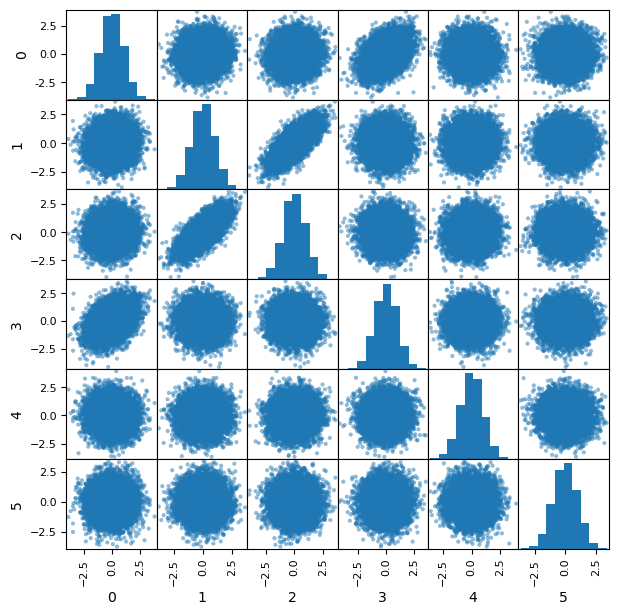

In [131]:
print(f"factor weights\n{a}\n")
pd.plotting.scatter_matrix(pd.DataFrame(U), figsize=(7,7))
plt.show()

In [125]:
print("correlation matrix of the randomly generated series")
corr_mat = np.corrcoef(U.T)
print(np.round(corr_mat,3))

correlation matrix of the randomly generated series
[[ 1.     0.097  0.105  0.4   -0.009 -0.006]
 [ 0.097  1.     0.717  0.002 -0.002  0.011]
 [ 0.105  0.717  1.     0.013  0.011  0.005]
 [ 0.4    0.002  0.013  1.    -0.018 -0.01 ]
 [-0.009 -0.002  0.011 -0.018  1.    -0.011]
 [-0.006  0.011  0.005 -0.01  -0.011  1.   ]]


# correlation matrix

$corr(U_i, U_j) = \sum_{m=1} ^M a_{im} * a_{jm}$

where there are M factors

In [117]:
corr_mat_a = sum([np.outer(a1,a1) for a1 in a])
np.fill_diagonal(corr_mat_a, 1)

print("correlation matrix from the a's in the model specification")
corr_mat_a

correlation matrix from the a's in the model specification


array([[1.  , 0.09, 0.08, 0.4 , 0.  , 0.  ],
       [0.09, 1.  , 0.72, 0.  , 0.  , 0.  ],
       [0.08, 0.72, 1.  , 0.  , 0.  , 0.  ],
       [0.4 , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 1.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ]])

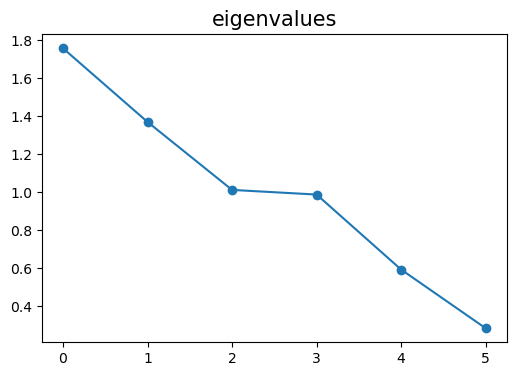

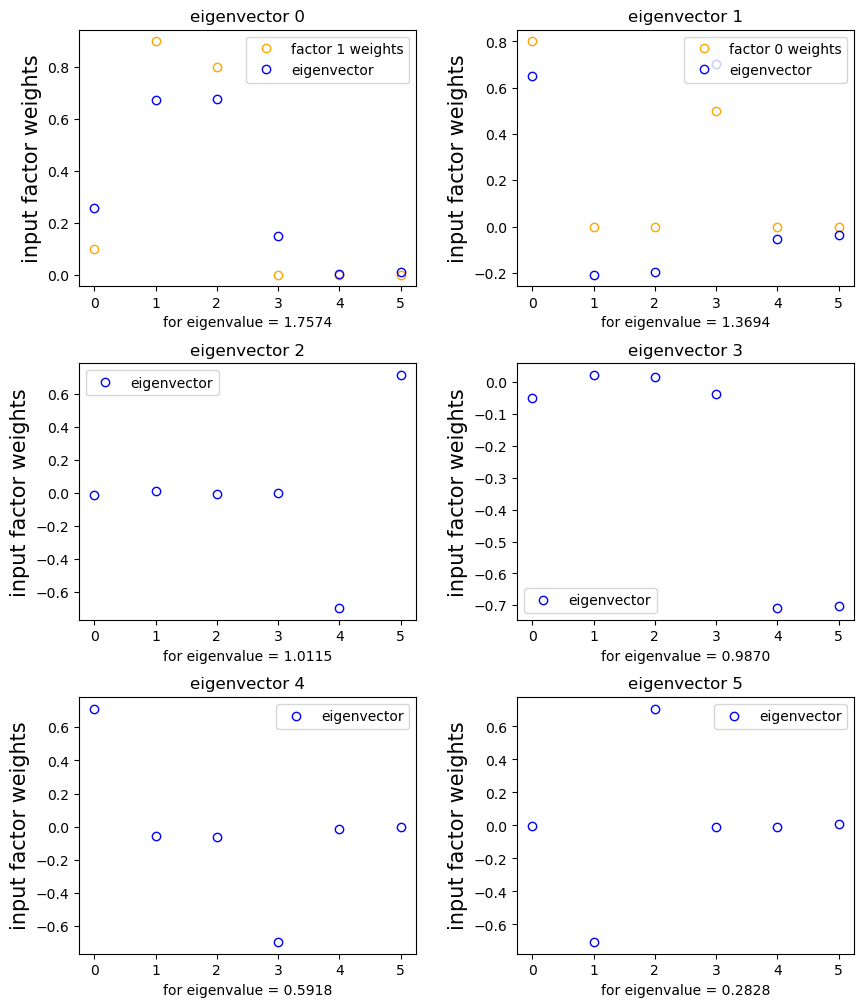

In [122]:
A = np.array(corr_mat, dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(A)

ranked_evals = sorted(enumerate(eigenvalues), key=lambda x: x[1], reverse=True)
ranks = [i for i,_ in ranked_evals]

plt.figure(figsize=(6, 4))
plt.plot([eval for i,eval in ranked_evals], 'o-')
plt.title("eigenvalues", fontsize=15)
plt.show()

print()
fig, axs = plt.subplots(int(n_investments / 2), 2, figsize=(10, 12))
plt.subplots_adjust(wspace=.3, hspace=.3)

ii,jj = 0,0
for i, (eval_rank, eval) in enumerate(ranked_evals):
    if i < 2:
        acorr_sign = np.sign(np.corrcoef(a[1-i], eigenvectors.T[eval_rank])[0,1])
        axs[ii,jj].plot(acorr_sign * a[1-i], 'o', markerfacecolor='none', color="orange", label=f"factor {1-i} weights")
    axs[ii,jj].plot(eigenvectors.T[eval_rank], 'o', markerfacecolor='none', color="blue", label="eigenvector")
    axs[ii,jj].set_ylabel("input factor weights", fontsize=15)
    axs[ii,jj].set_xlabel(f"for eigenvalue = {eval:0.4f}")
    axs[ii,jj].set_title(f"eigenvector {i}", fontsize=12)
    axs[ii,jj].legend()
    jj += 1
    if jj == 2:
        jj = 0
        ii += 1
plt.show()

In [123]:
# Perform Cholesky decomposition
cholesky_matrix = np.linalg.cholesky(corr_mat)

# Display the Cholesky matrix
print("Cholesky decomposition:")
print(np.round(cholesky_matrix,4))

Cholesky decomposition:
[[ 1.      0.      0.      0.      0.      0.    ]
 [ 0.0967  0.9953  0.      0.      0.      0.    ]
 [ 0.1047  0.7102  0.6961  0.      0.      0.    ]
 [ 0.4003 -0.0365 -0.0045  0.9157  0.      0.    ]
 [-0.0093 -0.001   0.0176 -0.0154  0.9997  0.    ]
 [-0.0063  0.0121 -0.0041 -0.0074 -0.0115  0.9998]]
